In [5]:
from pathlib import Path
import joblib
import pandas as pd
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

Root del progetto identificata: c:\Users\Davec\Documents\GitHub\Customer-Churn-Prediction-System
--- Step 1: Caricamento Risorse ---
Modello e file (1409, 27) caricati correttamente.
Verifica modello su dati di test (test_raw.csv):
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



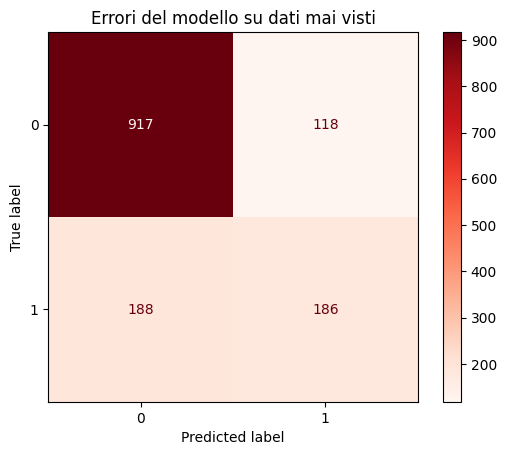

In [7]:
ROOT = Path.cwd().parents[0] # Assumendo che questo notebaook sia in ml/ e vogliamo risalire alla root del progetto

DATA_DIR = ROOT / "data" / "processed" 
print(f"Root del progetto identificata: {ROOT}")
MODELS_DIR = ROOT / "models"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)


print(f"--- Step 1: Caricamento Risorse ---")
# Caricamento Modello
pipeline = joblib.load(MODELS_DIR / "churn_pipeline_v1.joblib")

# Caricamento Dati di Test (Corretto il path per evitare duplicazioni)
df_test = pd.read_csv(DATA_DIR / "test_raw.csv")
print(f"Modello e file {df_test.shape} caricati correttamente.")

# Colonne da escludere (identificativi o coordinate geografiche non predittive)
drop_cols = ['Lat Long', 'Latitude', 'Longitude', 'Churn Value']

# Definizione di X (feature) e y (target)
X_test = df_test.drop(columns=drop_cols)
y_test = df_test['Churn Value']

# Verifica performance
print("Verifica modello su dati di test (test_raw.csv):")
preds = pipeline.predict(X_test)
print(classification_report(y_test, preds))

# Visualizzazione Errori
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap='Reds')
plt.title("Errori del modello su dati mai visti")
plt.show()

In [ ]:
pipeline = joblib.load(MODELS_DIR / "churn_pipeline_v1.joblib")

In [ ]:
df_test = pd.read_csv(PROC_DIR / "Telco_customer_churn.csv")
df_test['Total Charges'] = pd.to_numeric(df_test['Total Charges'], errors='coerce')

In [ ]:
target_col = "Churn Value"

In [ ]:
# Rimozione colonne non predittive (devono essere le stesse rimosse in training)
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 
             'Latitude', 'Longitude', 'Churn Label', 'Churn Value', 'Churn Reason']

In [ ]:
X_test = df_test.drop(columns=drop_cols)
y_test = df_test[target_col]

In [ ]:
preds = pipeline.predict(X_test)
proba = pipeline.predict_proba(X_test)[:,1]

In [ ]:
metrics = {
    "accuracy": accuracy_score(y_test, preds),
    "precision": precision_score(y_test, preds),
    "recall": recall_score(y_test, preds),
    "roc_auc": roc_auc_score(y_test, proba)
}

In [ ]:
print(f"Recall: {metrics['recall']:.2f}") # Indica quanti dei 'churnati' reali abbiamo preso

In [ ]:
pd.DataFrame([metrics]).to_csv(OUT_DIR / "metrics.csv", index=False)

In [ ]:
# Opzionale: Creazione di un report di classificazione testuale
from sklearn.metrics import classification_report
report = classification_report(y_test, preds)
with open(OUT_DIR / "classification_report.txt", "w") as f:
    f.write(report)

In [ ]:
# Aggiungi questo in evaluate.py
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)
plt.title("Matrice di Confusione - Errori del modello")
plt.show()